In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.6 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/Felix982/XAI-project.git
%cd XAI-project

import os, sys
sys.path.append(os.getcwd())

Cloning into 'XAI-project'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 32 (delta 3), reused 31 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 44.76 KiB | 4.07 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/XAI-project


In [3]:
import os
import sys
import torch
import matplotlib.pyplot as plt
from collections import Counter

sys.path.append(os.getcwd())

from data.medmnist import get_dataloader

In [4]:
train_loader = get_dataloader(
    split="train",
    batch_size=16,
    image_size=32,
    root="./data",
    num_workers=2,
)

batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

print("images.shape:", images.shape)
print("labels.shape:", labels.shape)
print("images.dtype:", images.dtype)
print("labels.dtype:", labels.dtype)
print("images.min/max:", images.min().item(), images.max().item())
print("labels[:10]:", labels[:10])

100%|██████████| 4.17M/4.17M [00:01<00:00, 2.27MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


images.shape: torch.Size([16, 1, 32, 32])
labels.shape: torch.Size([16])
images.dtype: torch.float32
labels.dtype: torch.int64
images.min/max: -1.0 0.7960784435272217
labels[:10]: tensor([1, 1, 0, 1, 1, 1, 1, 1, 1, 1])


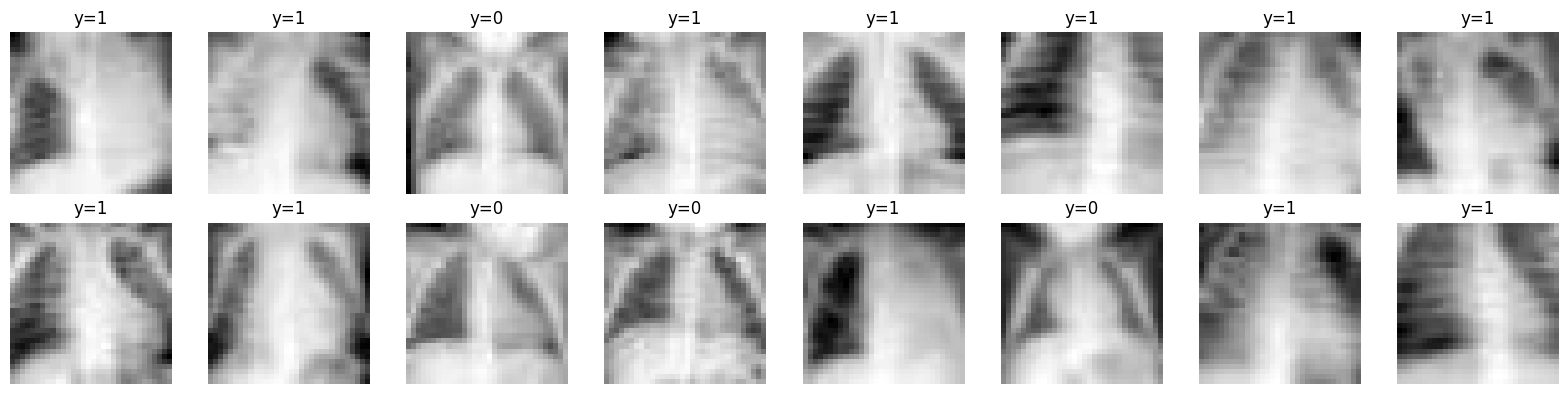

In [5]:
def denormalize(x):
    return (x * 0.5) + 0.5

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes = axes.flatten()

for i in range(16):
    img = denormalize(images[i]).squeeze().cpu().numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"y={labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
counter = Counter()

for batch in train_loader:
    ys = batch["label"].tolist()
    counter.update(ys)

print(counter)

Counter({1: 3494, 0: 1214})


In [7]:
total = sum(counter.values())
for cls, count in sorted(counter.items()):
    print(f"class {cls}: {count} ({count/total:.3f})")

class 0: 1214 (0.258)
class 1: 3494 (0.742)


In [8]:
for split in ["train", "val", "test"]:
    loader = get_dataloader(
        split=split,
        batch_size=8,
        image_size=32,
        root="./data",
        num_workers=2,
    )
    batch = next(iter(loader))
    print(split, batch["image"].shape, batch["label"].shape)

train torch.Size([8, 1, 32, 32]) torch.Size([8])
val torch.Size([8, 1, 32, 32]) torch.Size([8])
test torch.Size([8, 1, 32, 32]) torch.Size([8])


In [9]:
import torch
from models.classifier import SmallCNNClassifier

model = SmallCNNClassifier(in_channels=1, num_classes=2)
x = torch.randn(8, 1, 32, 32)
logits = model(x)

print("logits.shape:", logits.shape)

logits.shape: torch.Size([8, 2])


In [4]:
from training.train_classifier import TrainConfig, train_classifier

cfg = TrainConfig(
    data_root="./data",
    image_size=32,
    batch_size=128,
    num_workers=2,
    lr=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    output_dir="./outputs/classifier",
)

results = train_classifier(cfg)
results

100%|██████████| 4.17M/4.17M [00:00<00:00, 29.6MB/s]


Epoch 001 | train_loss=0.2124 | train_acc=0.9070 | val_loss=0.9968 | val_acc=0.7424
Epoch 002 | train_loss=0.1180 | train_acc=0.9541 | val_loss=0.2738 | val_acc=0.8760
Epoch 003 | train_loss=0.1012 | train_acc=0.9630 | val_loss=0.1437 | val_acc=0.9485
Epoch 004 | train_loss=0.0922 | train_acc=0.9645 | val_loss=0.1475 | val_acc=0.9466
Epoch 005 | train_loss=0.0890 | train_acc=0.9671 | val_loss=0.1561 | val_acc=0.9389
Epoch 006 | train_loss=0.0653 | train_acc=0.9749 | val_loss=0.0961 | val_acc=0.9695
Epoch 007 | train_loss=0.0583 | train_acc=0.9760 | val_loss=0.0704 | val_acc=0.9714
Epoch 008 | train_loss=0.0573 | train_acc=0.9777 | val_loss=0.1596 | val_acc=0.9408
Epoch 009 | train_loss=0.0487 | train_acc=0.9822 | val_loss=0.0737 | val_acc=0.9752
Epoch 010 | train_loss=0.0481 | train_acc=0.9813 | val_loss=0.7174 | val_acc=0.8015
Epoch 011 | train_loss=0.0485 | train_acc=0.9798 | val_loss=0.1906 | val_acc=0.9294
Epoch 012 | train_loss=0.0386 | train_acc=0.9847 | val_loss=0.0918 | val_acc

{'best_epoch': 7,
 'best_val_loss': 0.07044976631193671,
 'test_loss': 0.3358214864364037,
 'test_accuracy': 0.8958333333333334,
 'history': [{'epoch': 1,
   'train_loss': 0.2123748257490367,
   'train_accuracy': 0.9069668649107901,
   'val_loss': 0.9968052128799089,
   'val_accuracy': 0.7423664122137404},
  {'epoch': 2,
   'train_loss': 0.11799502650002047,
   'train_accuracy': 0.9541206457094308,
   'val_loss': 0.2737568170969723,
   'val_accuracy': 0.8759541984732825},
  {'epoch': 3,
   'train_loss': 0.10117638791605084,
   'train_accuracy': 0.9630416312659303,
   'val_loss': 0.14370701877215436,
   'val_accuracy': 0.9484732824427481},
  {'epoch': 4,
   'train_loss': 0.0921637549167127,
   'train_accuracy': 0.9645284621920136,
   'val_loss': 0.14750114265289016,
   'val_accuracy': 0.9465648854961832},
  {'epoch': 5,
   'train_loss': 0.08895222353689632,
   'train_accuracy': 0.9670773152081563,
   'val_loss': 0.15612947269705416,
   'val_accuracy': 0.9389312977099237},
  {'epoch': 6,

In [5]:
from google.colab import files

files.download("./outputs/classifier/classifier_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
files.download("./outputs/classifier/final_results.json")
files.download("./outputs/classifier/history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Code to load the model
import torch
from models.classifier import SmallCNNClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SmallCNNClassifier(in_channels=1, base_channels=32, dropout=0.1).to(device)
ckpt = torch.load("./outputs/classifier/classifier_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()